In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, signal, special
import itertools
import sympy as sp

In [26]:
t, xi, k1, k2, n, V = sp.symbols("t xi k1 k2 n V")

In [27]:
g1 = 1 + k2 * xi / (n - xi)
g2 = k1 * V

In [28]:
h1 = sp.integrate(g1, (xi, 0, xi))
h2 = sp.integrate(g2, (t, 0, t))

In [36]:
sol = sp.solve(sp.Eq(h1, h2), xi)
sol

[n*(k2*LambertW((1 - k2)*exp((-V*k1*t - k2*n + n)/(k2*n))/k2) + k2 - 1)/(k2 - 1)]

In [30]:
num, denum = sp.fraction(sol[0])
num

n*(k2*LambertW((1 - k2)*exp((-V*k1*t - k2*n + n)/(k2*n))/k2) + k2 - 1)

In [31]:
sp.limit(sp.diff(num, k2), k2, 1)

n - n*exp(-V*k1*t/n)

In [37]:
[sp.expand(sp.limit(sol[0], k2, 1))]

[n - n*exp(-V*k1*t/n)]

 - https://www.wolframalpha.com/input?i=limit+n0+*+%281+-+k2+%2F+%281+-+k2%29+*+lambertw%28%281+-+k2%29+%2F+k2+*+exp%28-+k1+*+V+*+t+%2F+%28n0+*+k2%29+%2B+%281+-+k2%29+%2F+k2%29%29%29+as+k2+-%3E+1

$$
\lim\limits_{k_2 \rightarrow 1} \xi = n_0 \left(1 - \exp\left(-\frac{k_1 V t}{n_0}\right)\right)
$$

## Analytical Solution

In [12]:
R = 8.31446261815324           # J/mol.K
T0 = 292.05                    # K
p0 = 101600                    # Pa
V = 190e-6                     # m3 of isopropanol
m = 2.7677                     # g of Raney Nickel
rho = 785                      # kg/m³
M = 60.1                       # g/mol
n0 = 1000 * rho * V / M        # mol

In [3]:
def model1(t, k1, k2):
    if k2 != 1.:
        return np.real(n0 * (1 - k2 / (1 - k2) * special.lambertw((1 - k2) / k2 * np.exp(- k1 * V * t / (n0 * k2) + (1 - k2) / k2))))
    else:
        return n0 * (1. - np.exp(- (k1 * t * V) / n0))

In [4]:
k1s = [1e-2, 1e-1]
k2s = [0.01, 0.1, 1.0000, 10., 100.]

In [5]:
tlin = np.linspace(0, 200_000, 500)

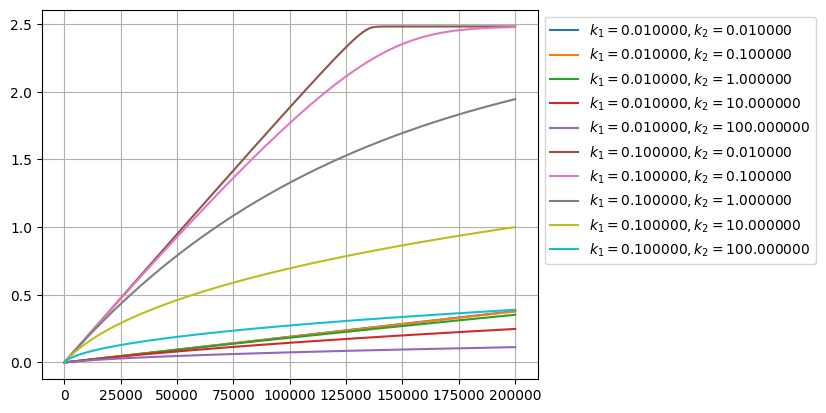

In [6]:
fig, axe = plt.subplots()
for k1, k2 in itertools.product(k1s, k2s):
    ylin = model1(tlin, k1, k2)
    axe.plot(tlin, ylin, label=r"$k_1 = %f, k_2 = %f$" % (k1, k2))
axe.legend(bbox_to_anchor=(1,1))
axe.grid()

In [9]:
k1s = [1e-1]
k2s = [0.99, 0.999, 1.000, 1.001, 1.01]

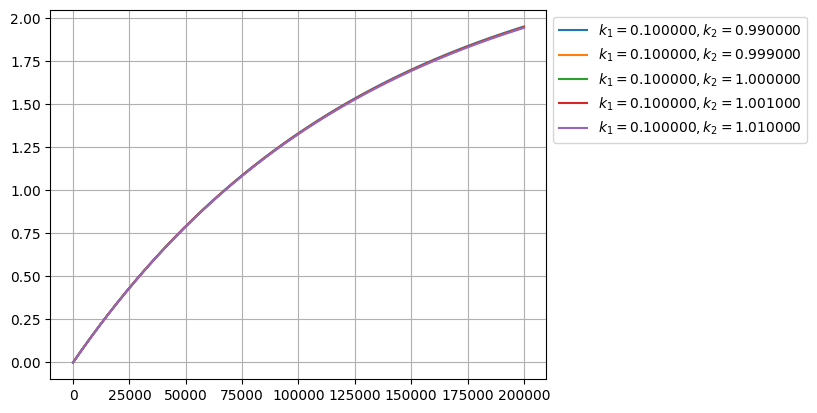

In [10]:
fig, axe = plt.subplots()
for k1, k2 in itertools.product(k1s, k2s):
    ylin = model1(tlin, k1, k2)
    axe.plot(tlin, ylin, label=r"$k_1 = %f, k_2 = %f$" % (k1, k2))
axe.legend(bbox_to_anchor=(1,1))
axe.grid()